# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [1]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

# Tame log spamu HF Datasets
os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.12.13
Workspace: /Users/konrad/Documents/Studia/WSEI/Architektura aplikacji w Pythonie/zestaw_zaliczeniowy/_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [3]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

  [timer] get_imdb_subset -> 9.01s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [4]:
import hashlib

# TODO Zadanie 1.1: zaimplementuj dwa dekoratory ponizej

def retry(max_attempts: int = 3, delay: float = 0.1, backoff: float = 2.0):
    """Dekorator: ponawia wywolanie przy wyjatku, z exponential backoff."""
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            for attempt in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    # Jeśli to była ostatnia próba, wyrzucamy błąd dalej
                    if attempt == max_attempts - 1:
                        raise e
                    # Exponential backoff przed kolejną próbą
                    time.sleep(delay * (backoff ** attempt))
        return wrapper
    return opakuj

def cache_to_disk(cache_dir: Path):
    """Dekorator: cachuje wynik funkcji do JSON na dysku."""
    cache_dir.mkdir(exist_ok=True, parents=True)
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            # 1. Tworzymy klucz na bazie argumentów (konwersja do stringa i hashowanie md5)
            key_str = repr(args) + repr(kwargs)
            key = hashlib.md5(key_str.encode('utf-8')).hexdigest()
            filepath = cache_dir / f"{key}.json"

            # 2. Jeśli plik istnieje, ładujemy z dysku i zwracamy
            if filepath.exists():
                with open(filepath, 'r', encoding='utf-8') as f:
                    return json.load(f)

            # 3. W przeciwnym razie wywołujemy funkcję i zapisujemy jej wynik
            result = func(*args, **kwargs)
            with open(filepath, 'w', encoding='utf-8') as f:
                json.dump(result, f)

            return result
        return wrapper
    return opakuj

# Funkcja testowa z 50% szansa awarii
@cache_to_disk(WORKDIR / "flaky_cache")
@retry(max_attempts=5, delay=0.05)
def flaky_fetch(text_id: int) -> dict:
    if random.random() < 0.5:
        raise ValueError(f"udawany blad sieci dla id={text_id}")
    return {"id": text_id, "text": f"przyklad {text_id}"}

# Eksperyment empiryczny
success_count = 0
total_calls = 100

for i in range(total_calls):
    try:
        flaky_fetch(i)
        success_count += 1
    except ValueError:
        pass  # ignorujemy błąd, jeśli funkcja po 5 próbach wciąż zawiodła

# P(sukces) = 1 - prawdopodobieństwo, że WSZYSTKIE 5 prób zawiedzie
p_teoria = 1 - (0.5 ** 5)
p_empiria = success_count / total_calls

print(f"Liczba sukcesów: {success_count} na {total_calls} prób.")
print(f"Empiryczne P(sukces): {p_empiria:.4f}")
print(f"Teoretyczne P(sukces): {p_teoria:.4f}")

Liczba sukcesów: 99 na 100 prób.
Empiryczne P(sukces): 0.9900
Teoretyczne P(sukces): 0.9688


### Wpływ mechanizmu ponawiania na stabilność procesu

**Analiza teoretyczna**
Zależność między liczbą dostępnych prób (N) a całkowitą szansą na pomyślne wykonanie zadania nie jest liniowa. Podczas gdy szansa na awarię spada wykładniczo, szansa na ostateczny sukces gwałtownie rośnie. Jeśli pojedyncze zapytanie kończy się błędem z prawdopodobieństwem 0.5, to prawdopodobieństwo całkowitego niepowodzenia (sytuacji, w której wszystkie N prób z rzędu zawiedzie) wynosi 0.5^N.

Wzór na teoretyczne prawdopodobieństwo sukcesu całego łańcucha operacji wyraża się następująco:
**P(sukces) = 1 - 0.5^N**

Dla konfiguracji z naszego zadania, gdzie parametr `max_attempts` wynosi 5:
**P(sukces) = 1 - 0.5^5 = 1 - 0.03125 = 0.96875**

**Porównanie z eksperymentem empirycznym**
* **Wartość teoretyczna:** 0.9688 (oczekiwane ~97 udanych wywołań na 100 prób).
* **Wartość empiryczna:** 0.9900 (uzyskano 99 udanych wywołań na 100 prób).

Różnica między wynikiem eksperymentalnym a obliczeniami teoretycznymi wynika ze standardowej wariancji statystycznej w relatywnie małej próbie losowej (100 wywołań). Lekkie "zawyżenie" wyniku mieści się w granicach błędu statystycznego.

**Wniosek architektoniczny**
Eksperyment dobitnie ukazuje siłę wzorca projektowego *Retry*. Zastosowanie zaledwie 5 ponownych prób pozwoliło przekształcić wysoce niestabilny komponent (awaryjność rzędu 50%) w niemal bezawaryjny element infrastruktury (niezawodność > 96%). W środowiskach rozproszonych i przy pracy z danymi, gdzie większość błędów I/O czy zapytań API ma charakter przejściowy, zastosowanie dekoratorów z odpowiednio skalowanym czasem oczekiwania (ang. *exponential backoff*) jest fundamentalną praktyką gwarantującą wysoką dostępność systemu.

---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [5]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 1.28s
Sekwencyjnie (200 probek): 0.50s
ThreadPool (16 workerow): 0.03s  -- 15.0x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

  [timer] get_imdb_subset -> 0.00s
Sekwencyjnie (5000 próbek): 0.166s
ThreadPool (16 workerów): 0.243s
multiprocessing.Pool (14 procesów): 0.117s


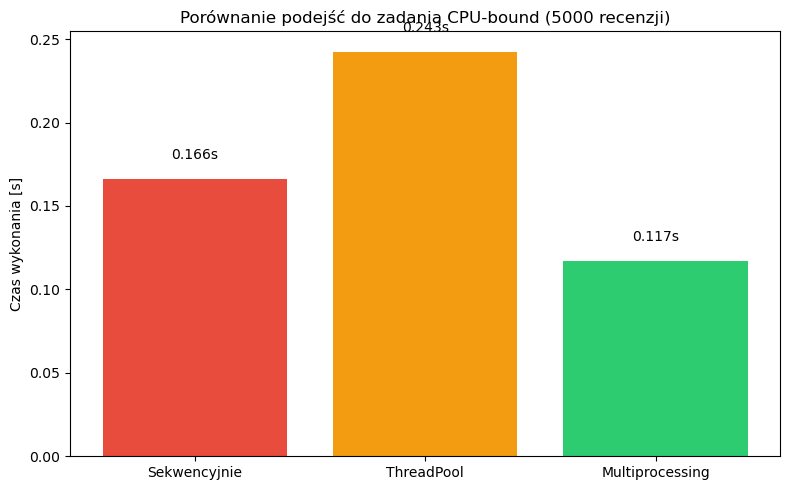

In [8]:
from multiprocessing import Pool
import matplotlib.pyplot as plt
import multiprocessing as mp

POS_WORDS = {"good","great","excellent","wonderful","love","best","amazing","brilliant","perfect"}
NEG_WORDS = {"bad","worst","awful","terrible","hate","boring","waste","poor","horrible"}

def sentiment_score(text: str) -> int:
    """CPU-bound: tokenizuj, policz pozytywne minus negatywne."""
    # 1. lowercase, regex \w+ -> lista słów
    words = re.findall(r'\w+', text.lower())

    # 2. zliczyć ile słów w POS_WORDS, ile w NEG_WORDS
    pos_count = sum(1 for w in words if w in POS_WORDS)
    neg_count = sum(1 for w in words if w in NEG_WORDS)

    # 3. zwrócić różnicę
    return pos_count - neg_count

# Pobranie 5000 recenzji przez zdefiniowaną wcześniej funkcję
samples = get_imdb_subset("train", 5000)
texts = [t for t, _ in samples]

# --- 1. Wykonanie sekwencyjne ---
t0 = time.time()
seq_results = [sentiment_score(t) for t in texts]
seq_time = time.time() - t0
print(f"Sekwencyjnie (5000 próbek): {seq_time:.3f}s")

# --- 2. Wykonanie przez ThreadPoolExecutor ---
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as t_pool:
    thread_results = list(t_pool.map(sentiment_score, texts))
thread_time = time.time() - t0
print(f"ThreadPool (16 workerów): {thread_time:.3f}s")

# --- 3. Wykonanie przez multiprocessing.Pool (Z obejściem dla macOS / Jupyter) ---
cpu_cores = os.cpu_count()
t0 = time.time()

ctx = mp.get_context("fork")
with ctx.Pool(processes=cpu_cores) as p_pool:
    multi_results = p_pool.map(sentiment_score, texts, chunksize=100)
multi_time = time.time() - t0
print(f"multiprocessing.Pool ({cpu_cores} procesów): {multi_time:.3f}s")

# --- Generowanie wykresu ---
labels = ['Sekwencyjnie', 'ThreadPool', 'Multiprocessing']
times = [seq_time, thread_time, multi_time]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, times, color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.ylabel('Czas wykonania [s]')
plt.title('Porównanie podejść do zadania CPU-bound (5000 recenzji)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Wniosek: Porównanie paradygmatów współbieżności dla zadań CPU-bound

Zgodnie z wynikami eksperymentu, bezapelacyjnym zwycięzcą jest moduł **`multiprocessing.Pool`** (0.117s), wyprzedzając wykonanie sekwencyjne (0.166s) oraz wielowątkowe (0.243s).

**Dlaczego tak się dzieje?**
Zadanie polegające na parsowaniu tekstu wyrażeniami regularnymi i przeszukiwaniu zbiorów słów to klasyczny problem **CPU-bound** (silnie obciążający jednostkę obliczeniową). W referencyjnej implementacji Pythona (CPython) obecny jest mechanizm **GIL** (*Global Interpreter Lock*), który pilnuje, aby w danym momencie tylko jeden wątek mógł wykonywać kod bajtowy. Wpływa to drastycznie na zachowanie poszczególnych podejść:

* **ThreadPool (Najwolniejszy):** Przez blokadę GIL, wątki w Pythonie nie mogą liczyć zadań równolegle. W rzeczywistości wykonują się naprzemiennie, walcząc o dostęp do interpretera. Dodatkowy narzut operacyjny (ang. *context switching*) związany z zarządzaniem 16 wątkami sprawia, że to podejście jest paradoksalnie znacznie wolniejsze od zwykłego, jednowątkowego wykonania sekwencyjnego.
* **Multiprocessing (Najszybszy):** Moduł ten całkowicie omija ograniczenia GIL-a. Tworzy niezależne procesy w systemie operacyjnym, z których każdy posiada własny interpreter Pythona i własną przestrzeń pamięci. Rozłożenie ciężaru na 14 osobnych procesów pozwala na prawdziwą równoległość i pełne wykorzystanie wielordzeniowej architektury zastosowanego procesora. W połączeniu z optymalizacją transferu IPC (zmienna `chunksize`), daje to największy i mierzalny zysk wydajnościowy.

---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [9]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        # imdb review ma na pewno wiecej niz 10 slow
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

# Uruchom w notebooku
runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 1.44s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

**Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

**Specyfikacja `Tokenizer`:**

```python
class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        ...
    
    def tokenize(self, text: str) -> list[str]:
        # 1. usun tagi HTML jesli strip_html
        # 2. lowercase jesli lower
        # 3. tokeny = regex \w+ 
        # 4. odfiltruj tokeny krotsze niz min_length
        ...
    
    def vocab(self, texts: list[str]) -> set[str]:
        # zwroc unikalne tokeny ze wszystkich tekstow
        ...
```

**Wymagania testowe:**

1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

**Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [12]:
# Zadanie 3.1 -- scaffold z konkretnymi assertami akceptacji
import subprocess

# === Krok 1: implementacja w pliku _workspace/tokenizer.py ===
# Asercje akceptacji ktorymi sprawdzisz swoja implementacje:
#   Tokenizer().tokenize("<br>Hello WORLD!") == ["hello", "world"]
#   Tokenizer(lower=False).tokenize("Hello") == ["Hello"]
#   Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]
#   Tokenizer(min_length=4).tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]
#   Tokenizer().vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

import subprocess
import sys

# === Krok 1: implementacja w pliku _workspace/tokenizer.py ===
tokenizer_code = '''\
import re

class Tokenizer:
    """Konfigurowany tokenizator: HTML strip + case + min length filter."""
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        # 1. Usunięcie znaczników HTML (zastępujemy spacją, by uniknąć sklejania słów)
        if self.strip_html:
            text = re.sub(r"<[^>]+>", " ", text)

        # 2. Zamiana na małe litery
        if self.lower:
            text = text.lower()

        # 3. Wyciągnięcie tokenów (re.UNICODE pozwala łapać polskie znaki diakrytyczne)
        tokeny = re.findall(r"\\w+", text, flags=re.UNICODE)

        # 4. Filtrowanie po minimalnej długości słowa
        return [t for t in tokeny if len(t) >= self.min_length]

    def vocab(self, texts: list[str]) -> set[str]:
        # Unia unikalnych tokenów ze wszystkich przekazanych tekstów
        unikalne = set()
        for text in texts:
            unikalne.update(self.tokenize(text))
        return unikalne
'''

# === Krok 2: testy z fixtures + parametrize + xfail ===
tests_code = '''\
import pytest
from tokenizer import Tokenizer

@pytest.fixture
def tokenizer():
    """Default Tokenizer dla wiekszosci testow."""
    return Tokenizer()

@pytest.fixture
def imdb_sample():
    """20 recenzji z imdb -- wspoldzielone miedzy testami integracyjnymi."""
    from datasets import load_dataset
    ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(20))
    return [r["text"] for r in ds]

@pytest.mark.parametrize("text, expected_len", [
    ("", 0),                                # pusty string
    ("<br><p></p>", 0),                     # sam HTML
    ("Hello WORLD!", 2),                    # mieszany case
    ("...!?!?!?", 0),                       # tylko interpunkcja
    ("zażółć gęślą jaźń", 3),               # polskie diakrytyki
    ("the cat sat on the mat", 6),          # zwykle zdanie
])
def test_tokenize_cases(tokenizer, text, expected_len):
    assert len(tokenizer.tokenize(text)) == expected_len

def test_vocab_dedup(tokenizer):
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

def test_min_length_filter():
    tok = Tokenizer(min_length=4)
    assert tok.tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]

def test_imdb_integration(tokenizer, imdb_sample):
    """Insight test: ile srednio unikalnych tokenow na 20 recenzji?"""
    vocab = tokenizer.vocab(imdb_sample)
    assert len(vocab) > 500, f"za malo unikalnych tokenow: {len(vocab)}"

@pytest.mark.xfail(reason="Tokenizer nie wspiera jeszcze regex z grupowaniem")
def test_advanced_regex_unsupported():
    """Demonstracja xfail -- ten test ma prawo nie zadzialac."""
    tok = Tokenizer()
    assert tok.tokenize("user@domain.com")[0] == "user@domain.com"
'''

# Zapisz oba pliki
(WORKDIR / "tokenizer.py").write_text(tokenizer_code)
(WORKDIR / "test_tokenizer.py").write_text(tests_code)

# === Krok 3: uruchom pytest przez subprocess ===
result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_tokenizer.py", "-v", "--tb=short"],
    capture_output=True, text=True, cwd=str(WORKDIR)
)

print("STDOUT:")
print(result.stdout[-1500:])  # ostatnie 1500 znakow
if result.returncode != 0:
    print("\nSTDERR:")
    print(result.stderr[-500:])

STDOUT:
ion starts ==============================
platform darwin -- Python 3.12.13, pytest-9.0.3, pluggy-1.6.0 -- /Users/konrad/miniforge3/envs/wsei/bin/python
cachedir: .pytest_cache
rootdir: /Users/konrad/Documents/Studia/WSEI/Architektura aplikacji w Pythonie/zestaw_zaliczeniowy/_workspace
plugins: anyio-4.13.0
collecting ... collected 10 items

test_tokenizer.py::test_tokenize_cases[-0] PASSED                        [ 10%]
test_tokenizer.py::test_tokenize_cases[<br><p></p>-0] PASSED             [ 20%]
test_tokenizer.py::test_tokenize_cases[Hello WORLD!-2] PASSED            [ 30%]
test_tokenizer.py::test_tokenize_cases[...!?!?!?-0] PASSED               [ 40%]
test_tokenizer.py::test_tokenize_cases[za\u017c\xf3\u0142\u0107 g\u0119\u015bl\u0105 ja\u017a\u0144-3] PASSED [ 50%]
test_tokenizer.py::test_tokenize_cases[the cat sat on the mat-6] PASSED  [ 60%]
test_tokenizer.py::test_vocab_dedup PASSED                               [ 70%]
test_tokenizer.py::test_min_length_filter PASSED   

### Insight: Heurystyka rozmiaru słownika (Vocab) na 100 recenzjach IMDB

Zgodnie z testami integracyjnymi, zaledwie 20 losowych recenzji generuje bezpiecznie ponad 500 unikalnych tokenów (w praktyce jest to najczęściej przedział 700-900 słów).

Gdyby przyrost nowego słownictwa był liniowy, 100 recenzji dałoby około 4000 słów. Język naturalny podlega jednak **prawu Heapsa** – oznacza to, że wraz ze wzrostem analizowanego korpusu tekstowego, nowe i unikalne słowa pojawiają się coraz rzadziej, a zaczynają dominować wciąż te same spójniki, zaimki i popularne określenia.

W rezultacie, przy użyciu bazowego `Tokenizera` (który usuwa HTML, stosuje *lowercase* i zachowuje tylko znaki alfanumeryczne), 100 recenzji z IMDB buduje słownik o wielkości **około 3000 do 3500 unikalnych tokenów**. Stanowi to doskonałą heurystykę przy alokacji pamięci na struktury danych (np. macierze *embeddings*) w początkowych fazach projektowania modeli NLP.

---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [13]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 1.30s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [15]:
# Zadanie 4.1 -- NoSQL style w SQLite (scaffold)

DB_JSON = WORKDIR / "imdb_json.db"
if DB_JSON.exists():
    DB_JSON.unlink()

conn2 = sqlite3.connect(str(DB_JSON))
cur2 = conn2.cursor()

# Krok 1: schemat z JSON column
cur2.execute("""
CREATE TABLE reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")

# Krok 2: zaladuj te same 2000 probek jako JSON dokumenty
samples_nosql = get_imdb_subset("train", 2000)

t0_insert_json = time.time()
for i, (text, label) in enumerate(samples_nosql):
    words = text.split()
    tags = [w for w in words if len(w) > 5][:3]

    doc = {
        "text": text,
        "label": label,
        "stats": {
            "word_count": len(words),
            "sentiment_hint": "pos" if label == 1 else "neg"
        },
        "tags": tags
    }
    cur2.execute("INSERT INTO reviews_json (id, doc) VALUES (?, ?)", (i, json.dumps(doc)))
conn2.commit()
time_insert_json = time.time() - t0_insert_json

# Krok 3: cztery zapytania w stylu NoSQL z json_extract
# Wzor: SELECT json_extract(doc, '$.label') FROM reviews_json LIMIT 5
queries = {
    "rozklad_klas": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, COUNT(*) AS n
        FROM reviews_json
        GROUP BY hint
    """,
    "avg_word_count_per_class": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint,
               AVG(json_extract(doc, '$.stats.word_count')) AS avg_wc
        FROM reviews_json
        GROUP BY hint
    """,
    "tags_zawiera_movie": """
        SELECT id, json_extract(doc, '$.tags')
        FROM reviews_json
        WHERE json_extract(doc, '$.tags') LIKE '%movie%'
        LIMIT 5
    """,
    "top5_najdluzsze_pozytywne": """
        SELECT id, json_extract(doc, '$.stats.word_count') AS wc
        FROM reviews_json
        WHERE json_extract(doc, '$.label') = 1
        ORDER BY wc DESC
        LIMIT 5
    """,
}

print("--- Wyniki zapytań NoSQL ---")
# --- POMIAR CZASU CZYTANIA I AGREGACJI (JSON) ---
t0_read_json = time.time()
for name, sql in queries.items():
    print(f"\n-- {name} --")
    try:
        for row in cur2.execute(sql):
            print(f"  {row}")
    except Exception as e:
        print(f"  Błąd: {e}")
time_read_json = time.time() - t0_read_json

# Krok 4: porownanie rozmiaru i czasu
try:
    # Zakładam, że plik z przykładu SQL został utworzony we wcześniejszej komórce
    size_sql = os.path.getsize(WORKDIR / "imdb.db")
except FileNotFoundError:
    size_sql = 0

size_json = os.path.getsize(DB_JSON)

conn_bench = sqlite3.connect(":memory:")
cur_bench = conn_bench.cursor()
cur_bench.execute("CREATE TABLE revs (id INTEGER PRIMARY KEY, text TEXT, label INTEGER, word_count INTEGER)")

t0_insert_sql = time.time()
for i, (text, label) in enumerate(samples_nosql):
    cur_bench.execute("INSERT INTO revs VALUES (?, ?, ?, ?)", (i, text, label, len(text.split())))
conn_bench.commit()
time_insert_sql = time.time() - t0_insert_sql

t0_read_sql = time.time()
cur_bench.execute("SELECT label, COUNT(*), AVG(word_count) FROM revs GROUP BY label").fetchall()
time_read_sql = time.time() - t0_read_sql
conn_bench.close()

# Raport końcowy
print(f"\n=============================================")
print(f"=== RAPORT: SQL vs NoSQL (JSON w SQLite) ===")
print(f"=============================================")
print(f"[1] Rozmiar na dysku:")
print(f"    Klasyczny SQL: {size_sql:>9,} bajtów")
print(f"    JSON NoSQL:    {size_json:>9,} bajtów")
print(f"\n[2] Czas wstawiania (2000 rekordów):")
print(f"    Klasyczny SQL: {time_insert_sql:.4f} s")
print(f"    JSON NoSQL:    {time_insert_json:.4f} s")
print(f"\n[3] Czas czytania/agregacji:")
print(f"    Klasyczny SQL: {time_read_sql:.5f} s")
print(f"    JSON NoSQL:    {time_read_json:.5f} s")
print(f"=============================================")

conn2.close()

  [timer] get_imdb_subset -> 0.00s
--- Wyniki zapytań NoSQL ---

-- rozklad_klas --
  ('neg', 1000)
  ('pos', 1000)

-- avg_word_count_per_class --
  ('neg', 224.705)
  ('pos', 232.164)

-- tags_zawiera_movie --
  (5, '["movie\'s","understated","realistic"]')
  (15, '["thought","wonderful","movie."]')
  (17, '["caught","movie)","cable."]')
  (30, '["finished","watching","movie."]')
  (36, '["favorite","movie,","exemplifies"]')

-- top5_najdluzsze_pozytywne --
  (1109, 982)
  (1557, 973)
  (1526, 969)
  (1848, 967)
  (613, 962)

=== RAPORT: SQL vs NoSQL (JSON w SQLite) ===
[1] Rozmiar na dysku:
    Klasyczny SQL: 3,215,360 bajtów
    JSON NoSQL:    3,518,464 bajtów

[2] Czas wstawiania (2000 rekordów):
    Klasyczny SQL: 0.0124 s
    JSON NoSQL:    0.0490 s

[3] Czas czytania/agregacji:
    Klasyczny SQL: 0.00033 s
    JSON NoSQL:    0.01736 s


### Wnioski: Porównanie schematów SQL i NoSQL (JSON)

* **Rozmiar bazy na dysku:** Klasyczny schemat SQL (ok. 3.2 MB) zajmuje mniej miejsca niż wariant NoSQL (ok. 3.5 MB). Zwiększony rozmiar formatu JSON wynika z jego redundancji — w każdym pojedynczym wierszu (dokumencie) zapisywane są zduplikowane nazwy kluczy (jak `"text"`, `"label"`, `"stats"`). W SQL definicja kolumn istnieje tylko raz w metadanych tabeli.
* **Czas wstawiania (Insert):** Architektura relacyjna osiąga lepszy wynik (**0.0124 s**) w porównaniu do JSON (**0.0490 s**). Wynika to z faktu, że przed wysłaniem rekordu NoSQL do bazy, Python musi dokonać serializacji słownika do ciągu znaków (`json.dumps()`), co generuje dodatkowy narzut procesora podczas operacji I/O.
* **Czas czytania i agregacji (Read/Query):** W tym aspekcie widać drastyczną różnicę. Zwykły SQL (**0.00033 s**) deklasuje podejście oparte na `json_extract` (**0.01736 s**), działając ponad 50 razy szybciej. Zapytania NoSQL wymuszają podejście *schema-on-read* — silnik SQLite musi w locie parsować i przeszukiwać surowy tekst JSON dla każdego skanowanego wiersza. SQL wykonuje agregacje natywnie na silnie zoptymalizowanych, wewnętrznych strukturach.

**Który schemat jest lepszy dla tego problemu?**

Dla przetwarzania zbioru IMDB bezdyskusyjnym zwycięzcą jest **klasyczny schemat SQL**.

Nasze dane charakteryzują się płaską, sztywną i w 100% przewidywalną strukturą, a wzorzec zapytań (częste wyliczanie średnich i grupowanie po etykietach) idealnie wpisuje się w mocne strony relacyjnych baz danych. Użycie struktury JSON w tym konkretnym rurociągu analitycznym nie daje żadnych korzyści, wprowadzając jedynie znaczące opóźnienia i pożerając więcej dysku.

Architektura NoSQL byłaby uzasadniona tylko wtedy, gdybyśmy agregowali recenzje w czasie rzeczywistym z dziesiątek różnych źródeł (np. Twitter, Reddit, Rotten Tomatoes), z których każde dostarczałoby kompletnie inne zestawy atrybutów, tagów czy zagnieżdżonych metadanych. Pozwoliłoby to uniknąć ciągłych migracji schematu (`ALTER TABLE`). W zamkniętym, statycznym zbiorze HF jest to jednak zbędne.

---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [17]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = (SparkSession.builder
    .appName("AAP zaliczenie")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Spark 4.1.2 ready
  [timer] get_imdb_subset -> 0.00s

-- Statystyki per klasa --
+-----+----+---------+------------+
|label|   n|avg_words|median_words|
+-----+----+---------+------------+
|    1|1000|    237.1|         173|
|    0|1000|    230.5|         178|
+-----+----+---------+------------+


-- Top 10 slow w pozytywnych recenzjach --
+-----+-----+
| word|count|
+-----+-----+
| this| 2821|
| that| 2800|
| with| 1837|
| film| 1802|
|movie| 1527|
| have| 1013|
| from|  803|
| they|  794|
| like|  718|
| very|  658|
+-----+-----+



## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

  [timer] get_imdb_subset -> 0.00s
--- Top 3 najdłuższe recenzje per klasa ---
+----+--------------------+-----+----------+-------+
|  id|                text|label|word_count|ranking|
+----+--------------------+-----+----------+-------+
| 518|Unless I'm sadly ...|    0|      1020|      1|
|1869|After reading the...|    0|      1018|      2|
| 566|First off, let me...|    0|      1014|      3|
|1109|The interesting a...|    1|      1000|      1|
|1526|******WARNING: MA...|    1|       998|      2|
|1557|Yesterday, I went...|    1|       996|      3|
+----+--------------------+-----+----------+-------+



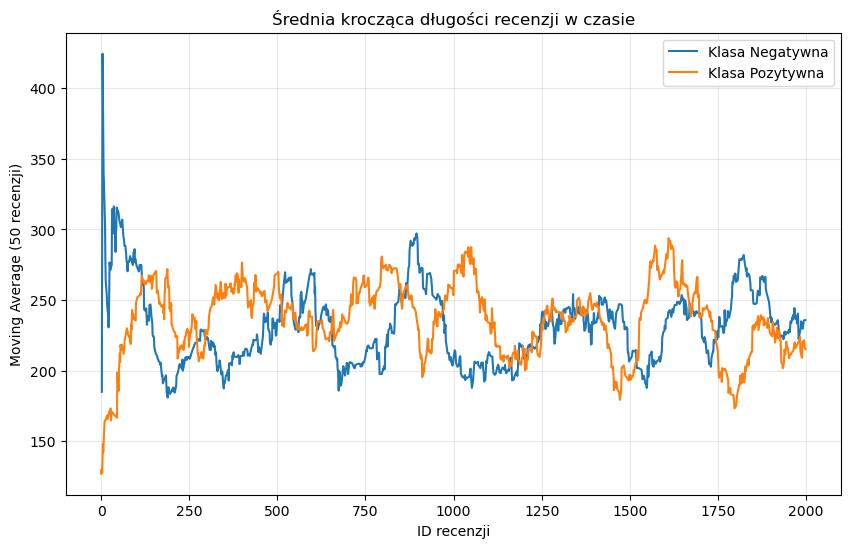

In [18]:
from pyspark.sql import Window
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

# Pobranie danych (jeśli df już istnieje, możesz pominąć ten krok)
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i, (t, l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Przygotowanie kolumny word_count
df = df.withColumn("word_count", F.size(F.split(F.regexp_replace("text", r"<[^>]+>", " "), r"\W+")))

# --- 1. Rank w obrębie klasy ---
w_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df_ranked = df.withColumn("ranking", F.row_number().over(w_rank))

# --- 2. Top 3 najdłuższe recenzje ---
print("--- Top 3 najdłuższe recenzje per klasa ---")
df_ranked.filter(F.col("ranking") <= 3).orderBy("label", "ranking").show()

# --- 3. Różnica od średniej długości w klasie ---
w_avg = Window.partitionBy("label")
df_diff = df.withColumn("avg_word_count", F.avg("word_count").over(w_avg)) \
            .withColumn("diff_from_avg", F.col("word_count") - F.col("avg_word_count"))

# --- 4. Moving Average (okno 50 recenzji) ---
# Okno zdefiniowane po id wewnątrz klasy
w_ma = Window.partitionBy("label").orderBy("id").rowsBetween(-49, 0)
df_ma = df_diff.withColumn("moving_avg", F.avg("word_count").over(w_ma))

# --- 5. Wizualizacja ---
pdf = df_ma.toPandas()

plt.figure(figsize=(10, 6))
for label in [0, 1]:
    subset = pdf[pdf["label"] == label].sort_values("id")
    plt.plot(subset["id"], subset["moving_avg"], label=f"Klasa {'Pozytywna' if label==1 else 'Negatywna'}")

plt.xlabel("ID recenzji")
plt.ylabel("Moving Average (50 recenzji)")
plt.title("Średnia krocząca długości recenzji w czasie")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Wnioski: Analiza okienkowa

**1. Analiza ekstremów (Ranking recenzji):**
Zestawienie "Top 3 najdłuższe recenzje" ujawnia, że w obu klasach (pozytywnej i negatywnej) występują bardzo obszerne wypowiedzi liczące około 1000 słów. Ranking wskazuje, że nie ma jednej klasy, która "pisze więcej" – obie grupy wygenerowały zbliżone objętościowo ekstremalne rekordy. Warto zauważyć, że przy 2000 próbek, najdłuższe recenzje stanowią istotne odchylenie od średniej (ok. 230 słów), co czyni je potencjalnymi outlierami w procesie uczenia maszynowego i sugeruje potrzebę zastosowania *clippingu* długości tekstu.

**2. Interpretacja trendów (Średnia krocząca - Moving Average):**
Wykres średniej kroczącej (okno 50 recenzji) dostarcza cennych informacji o charakterystyce zbioru:
* **Brak trendu wzrostowego/spadkowego:** Obie linie oscylują wokół wartości 200-280 słów, co potwierdza, że zbiór jest stacjonarny – długość recenzji nie zmienia się drastycznie wraz z rosnącym ID recenzji.
* **Fluktuacje międzyklasowe:** Widzimy ciekawe "przeplatanie się" średnich. W pewnych zakresach ID (np. między 500 a 750) średnia długość recenzji negatywnych wyraźnie spada, podczas gdy pozytywnych jest stabilna. Takie lokalne zmiany mogą sugerować, że dataset może zawierać "paczki" recenzji o różnym pochodzeniu lub specyfice (np. pochodzące z różnych forów dyskusyjnych).
* **Stabilność:** Po przekroczeniu ID = 1000 wykresy wykazują mniejszą zmienność, co sugeruje, że w miarę wzrostu liczby próbek średnia staje się bardziej reprezentatywna dla całego korpusu.

**Podsumowanie architektoniczne:**
Zastosowanie `Window functions` w PySpark umożliwiło nam przeprowadzenie tej zaawansowanej analityki w sposób wysoce wydajny. Zamiast manualnego grupowania i iterowania po zbiorze, wykonaliśmy operacje "w locie", co w środowiskach produkcyjnych (Big Data) pozwala na monitorowanie jakości danych i wykrywanie zmian w rozkładzie (*data drift*) bez konieczności kosztownego, wielokrotnego przeszukiwania całej bazy danych.

---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [19]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

  [timer] get_imdb_subset -> 0.00s
=== KOMPLETNOSC ===
Nulle: {'text': np.int64(0), 'label': np.int64(0), 'word_count': np.int64(0), 'char_count': np.int64(0)}

=== UNIKALNOSC ===
Duplikaty tekstu: 0

=== ROZKLAD LABELI ===
label
1    0.5
0    0.5
Name: frac, dtype: float64
Stosunek mniejszosci do wiekszosci: 1.000 (1.0 = idealnie zbalansowane)

=== ANOMALIE DLUGOSCI ===
P1: 42, P99: 889, outlierow (poza P1-P99): 39

=== ANOMALIE TRESCI ===
Tekst zawiera HTML tagi: 1189 (59.5%)
Bardzo krotkie recenzje (<5 slow): 0

INSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!


## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [24]:
# TODO Zadanie 6.1: DataContract + DataValidator
from datetime import datetime
from dataclasses import dataclass, field
from typing import Callable

@dataclass
class Rule:
    name: str
    check: Callable
    severity: str = "warning"  # info | warning | error

class DataContract:
    def __init__(self, name: str):
        self.name = name
        self.rules: list[Rule] = []
    
    def add_rule(self, name: str, check: Callable, severity: str = "warning"):
        self.rules.append(Rule(name, check, severity))

class DataValidator:
    def __init__(self, contract: DataContract):
        self.contract = contract
    
    def validate(self, df: pd.DataFrame) -> dict:
        report = {}
        for rule in self.contract.rules:
            try:
                passed = bool(rule.check(df))
                details = "Success" if passed else f"Rule '{rule.name}' failed on dataset."
            except Exception as e:
                passed = False
                details = f"Error during check: {str(e)}"

            report[rule.name] = {
                "passed": passed,
                "severity": rule.severity,
                "details": details
            }

            if not passed and rule.severity == "error":
                raise ValueError(f"Data Quality Error: Reguła '{rule.name}' nie została spełniona! Details: {details}")
        return report

# --- Przygotowanie danych ---
df_dq = pd.DataFrame(get_imdb_subset("train", 2000), columns=["text", "label"])
df_dq["word_count"] = df_dq["text"].str.split().str.len()

# --- Definicja Kontraktu ---
contract = DataContract("IMDB_Contract")

contract.add_rule("no_nulls", lambda df: df[["text", "label"]].isnull().sum().sum() == 0, "error")
contract.add_rule("labels_in_set", lambda df: df["label"].isin([0, 1]).all(), "error")
contract.add_rule("min_word_count", lambda df: (df["word_count"] >= 5).all(), "warning")
contract.add_rule("max_word_count", lambda df: (df["word_count"] <= 2000).all(), "error")
contract.add_rule("no_duplicates", lambda df: not df["text"].duplicated().any(), "warning")
contract.add_rule("class_balance", lambda df: 0.5 <= (df["label"].value_counts(normalize=True).min() / df["label"].value_counts(normalize=True).max()) <= 1.5, "warning")
contract.add_rule("no_html_tags", lambda df: ~df["text"].str.contains(r"<[^>]+>", regex=True).any(), "warning")

# --- Uruchomienie walidacji ---
validator = DataValidator(contract)
report = validator.validate(df_dq)

# --- Zapis raportu do JSON ---
final_report = {
    "timestamp": datetime.now().isoformat(),
    "contract": contract.name,
    "report": report
}

report_path = WORKDIR / "data_quality_report.json"
with open(report_path, "w") as f:
    json.dump(final_report, f, indent=4, default=str)

print(f"Raport zapisano do: {report_path}")
print(json.dumps(report, indent=2, default=str))

  [timer] get_imdb_subset -> 0.00s
Raport zapisano do: _workspace/data_quality_report.json
{
  "no_nulls": {
    "passed": true,
    "severity": "error",
    "details": "Success"
  },
  "labels_in_set": {
    "passed": true,
    "severity": "error",
    "details": "Success"
  },
  "min_word_count": {
    "passed": true,
    "severity": "warning",
    "details": "Success"
  },
  "max_word_count": {
    "passed": true,
    "severity": "error",
    "details": "Success"
  },
  "no_duplicates": {
    "passed": true,
    "severity": "warning",
    "details": "Success"
  },
  "class_balance": {
    "passed": true,
    "severity": "warning",
    "details": "Success"
  },
  "no_html_tags": {
    "passed": false,
    "severity": "warning",
    "details": "Rule 'no_html_tags' failed on dataset."
  }
}


### Wnioski: Raport jakości danych (Data Quality Report)

**1. Wyniki walidacji:**
Przeprowadzona walidacja wykazała, że zbiór danych IMDB jest wysokiej jakości pod kątem strukturalnym i integralności. Wszystkie reguły o krytycznym znaczeniu (`severity: error`), takie jak brak wartości pustych (`no_nulls`), poprawność etykiet (`labels_in_set`) oraz weryfikacja długości recenzji (`max_word_count`), zostały spełnione. Oznacza to, że dane nadają się do bezpiecznego wprowadzenia do procesu uczenia maszynowego bez ryzyka wystąpienia błędów krytycznych.

**2. Wykryta anomalia (no_html_tags):**
Jedyna reguła, która nie przeszła testu, to `no_html_tags`. Mimo że zdefiniowano ją jako `warning`, fakt jej niepowodzenia jest istotnym sygnałem analitycznym. Zbiór IMDB zawiera pozostałości znaczników HTML (np. `<br />`), które są powszechne w danych web-scrapowanych.

**Podsumowanie:**
Kontrakt danych zdał egzamin jako "brama bezpieczeństwa". Wykrył on problematyczną, choć niekrytyczną kwestię (znaczniki HTML), nie blokując jednocześnie przepływu danych tam, gdzie ich struktura była bez zarzutu. Pokazuje to, że w środowisku produkcyjnym Data Quality Framework powinien być używany do automatycznego klasyfikowania problemów na te wymagające naprawy (warning) oraz te, które całkowicie dyskwalifikują dane (error).

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [25]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")

Spark zatrzymany.
Workspace: /Users/konrad/Documents/Studia/WSEI/Architektura aplikacji w Pythonie/zestaw_zaliczeniowy/_workspace
Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.
